# CPU Performance Comparison (Basic)

Razor's Edge vs fixed batch sizes 1, 2, 3, and 4 with random input lengths 1-200 chars.


In [1]:
from pathlib import Path
import sys
import os
import psutil

repo_root = Path.cwd()
while not (repo_root / "src").exists():
    if repo_root.parent == repo_root:
        raise RuntimeError("Could not find 'src' directory in any parent")
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

p = psutil.Process(os.getpid())
if psutil.WINDOWS:
    p.nice(psutil.HIGH_PRIORITY_CLASS)
else:
    try:
        p.nice(-10)
    except psutil.AccessDenied:
        print("Elevation (sudo) is required to set high priority on Unix.")


In [2]:
import asyncio
import time
import random
import string

import matplotlib.pyplot as plt

from batching_executor.process_manager import ComputeExecutor
from demos.cpu.razors_edge_cpu_benchmark_task import RazorsEdgeCPUBenchmarkTask
from demos.cpu.base_batched_cpu_benchmark_task import BaseBatchedCPUBenchmarkTask
from demos.cpu.base_batched_cpu_benchmark_task_variants import (
    BaseBatchedCPUBenchmarkTaskB2,
    BaseBatchedCPUBenchmarkTaskB3,
    BaseBatchedCPUBenchmarkTaskB4,
)


def generate_random_strings(n: int, a: int = 1, b: int = 200, seed: int = 42) -> list[str]:
    rng = random.Random(seed)
    chars = string.ascii_letters + string.digits + " "
    result = []
    for _ in range(n):
        length = rng.randint(a, b)
        rand_str = "".join(rng.choice(chars) for _ in range(length))
        result.append(rand_str)
    return result


## Start executor


In [3]:
executor = ComputeExecutor(
    [RazorsEdgeCPUBenchmarkTask, BaseBatchedCPUBenchmarkTask, BaseBatchedCPUBenchmarkTaskB2, BaseBatchedCPUBenchmarkTaskB3, BaseBatchedCPUBenchmarkTaskB4],
    async_limit=64,
    model_thread_limit=1,
)


## Basic functionality check


In [4]:
sample = executor.sync_compute_fn(RazorsEdgeCPUBenchmarkTask, "hello razors edge")
assert isinstance(sample, list)
assert len(sample) > 0
assert isinstance(sample[0], float)
print("sync check 1 passed")

sample = executor.sync_compute_fn(BaseBatchedCPUBenchmarkTask, "hello razors edge")
assert isinstance(sample, list)
assert len(sample) > 0
assert isinstance(sample[0], float)
print("sync check 2 passed")


sync check 1 passed
sync check 2 passed


## Benchmark helpers


In [5]:
async def benchmark_async(target, request_count: int, seed: int = 42) -> tuple[float, float]:
    payloads = generate_random_strings(request_count, 1, 200, seed=seed)
    start = time.perf_counter()
    await asyncio.gather(*(executor.async_compute_fn(target, payload) for payload in payloads))
    elapsed = time.perf_counter() - start
    return elapsed, request_count / elapsed


## Run timing benchmarks


In [6]:
n_req = 200
tasks = [RazorsEdgeCPUBenchmarkTask, BaseBatchedCPUBenchmarkTask, BaseBatchedCPUBenchmarkTaskB2, BaseBatchedCPUBenchmarkTaskB3, BaseBatchedCPUBenchmarkTaskB4]

rps_list = []
for task in tasks:
    a_elapsed, a_rps = await benchmark_async(task, n_req)
    rps_list.append(a_rps)
    print(f"Completed one benchmark for {task.__name__}: {a_rps:.2f} RPS")


Completed one benchmark for RazorsEdgeCPUBenchmarkTask: 16.46 RPS
Completed one benchmark for BaseBatchedCPUBenchmarkTask: 10.56 RPS
Completed one benchmark for BaseBatchedCPUBenchmarkTaskB2: 10.91 RPS
Completed one benchmark for BaseBatchedCPUBenchmarkTaskB3: 10.89 RPS
Completed one benchmark for BaseBatchedCPUBenchmarkTaskB4: 10.44 RPS


## Diagram: Throughput by scheduler


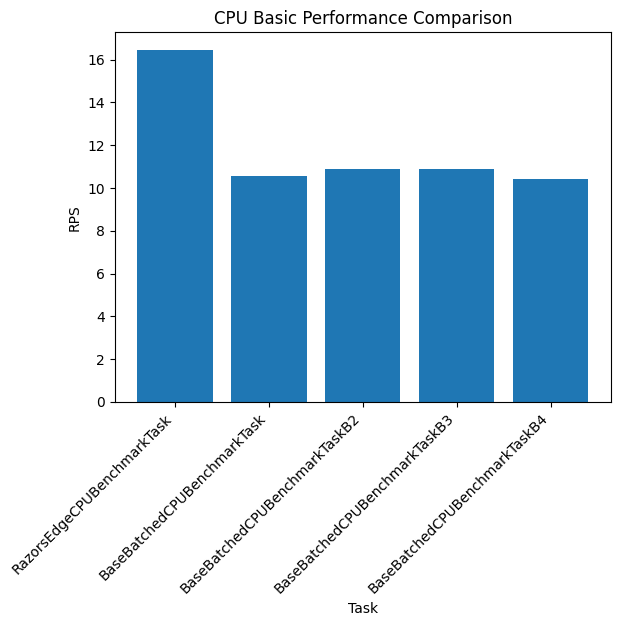

In [7]:
plt.bar([i.__name__ for i in tasks], rps_list)
plt.ylabel("RPS")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Task")
plt.title("CPU Basic Performance Comparison")
plt.savefig(Path("..") / ".." / "images" / f"{plt.gca().get_title()}.png", bbox_inches="tight")
plt.show()
